# Task 1 — Traffic model: estimate real visitor count

Build a sensor-to-footfall model calibrated against manual counting windows (assignment Task 1).

This notebook compares three clearly separated approaches:

- **Plan A** — trusted-device linear baseline (`footfall_plan_a` / `footfall_trusted_linear`)
- **Plan B** — capture rate + HOD v2 (`footfall_plan_b`) + mall visitors (`estimated_mall_visitors`)
- **Plan C** — trend-preserving clean-device elasticity (`footfall_plan_c`, delivered estimate)

**Workflow:** compute all plans from scratch → show summary tables → interactive Plan A/B/C dashboards → static plots.

Plots: `outputs/plots/task1/plan_a/`, `outputs/plots/task1/plan_b/`

In [1]:
from IPython.display import display

from notebook_helpers import (
    load_facilities,
    plot_task1,
    plot_task1_abc_interactive,
    prepare_task1_abc,
    run_task1,
    show_task_plots,
)

# Compute Task 1 from scratch (Plan A + Plan B; Plan C is produced in Plan A pipeline).
FORCE_RECOMPUTE = True

t1 = run_task1(force_recompute=FORCE_RECOMPUTE, plan="both")
plan_a = t1["plan_a"]
plan_b = t1["plan_b"]

# Ensure rich objects exist when loading from cache.
if "calibration" not in plan_a or "task1_result" not in plan_a:
    from notebook_helpers import run_plan_a
    plan_a = run_plan_a(force_recompute=True, write_outputs=True)
if "hourly" not in plan_b:
    from notebook_helpers import run_plan_b
    plan_b = run_plan_b(force_recompute=True, write_outputs=True)

task1_abc = prepare_task1_abc(plan_a, plan_b)
facilities = load_facilities()

display(task1_abc["overall_summary"])

mall_visitors = task1_abc.get("mall_visitors_weekly")
if mall_visitors == mall_visitors:
    display({"mall_visitors_weekly": mall_visitors})

display(task1_abc["facility_weekly"].head(10))

,plan,weekly_footfall,daily_average
0,Plan A,796063.56,113723.365714
1,Plan B,601278.07,85896.867143
2,Plan C,707210.21,101030.030000


{'mall_visitors_weekly': 383966.39999999997}

,facility_num,plan_a_estimate,plan_b_estimate,plan_c_estimate
4,66335,89915.78,95106.55,92757.38
0,66330,91132.80,42937.84,89128.54
7,66340,92599.02,134953.26,89031.57
5,66336,97758.31,89696.89,88789.95
1,66331,89483.36,21656.54,83473.31
8,66342,94638.27,101953.03,81423.19
2,66332,94267.07,73765.75,79675.46
3,66333,90277.81,40751.92,69995.66
6,66338,55991.14,456.29,32935.15


In [2]:
display(task1_abc["daily_compare"])
display(task1_abc["calibration_compare"])

if not task1_abc["mall_daily"].empty:
    display(task1_abc["mall_daily"])

,date,plan_a_estimate,plan_b_estimate,plan_c_estimate
0,2026-04-20,110340.73,74564.47,97453.78
1,2026-04-21,112108.21,41010.65,91470.95
2,2026-04-22,113679.91,75841.09,99979.64
3,2026-04-23,110989.30,67815.41,90914.00
4,2026-04-24,116607.37,92912.63,106925.19
5,2026-04-25,114715.54,139220.13,109576.51
6,2026-04-26,117622.50,109913.69,110890.14


,facility_num,started,manual_total_count,plan_a_pred,plan_c_pred,plan_b_pred,window_label
0,66330,2026-04-23 13:00:00,651.0,639.15,611.44,683.54,66330 | 2026-04-23 13:00
1,66330,2026-04-24 13:00:00,550.0,559.27,587.41,457.81,66330 | 2026-04-24 13:00
2,66333,2026-04-23 15:00:00,565.0,542.82,527.10,202.51,66333 | 2026-04-23 15:00
3,66333,2026-04-24 15:00:00,558.0,582.76,583.50,559.57,66333 | 2026-04-24 15:00


,date,unique_devices_mall,clean_sessions,sum_facility_uniques,footfall_plan_b,footfall_plan_a,estimated_mall_visitors
0,2026-04-20,252782,270265,266546,74564.47,110340.73,47114.07
1,2026-04-21,155877,169714,166885,41010.65,112108.21,29052.70
2,2026-04-22,255219,276625,272955,75841.09,113679.91,47568.29
3,2026-04-23,235150,250575,247378,67815.41,110989.30,43827.78
4,2026-04-24,313237,338396,334199,92912.63,116607.37,58381.81
5,2026-04-25,465724,509503,504120,139220.13,114715.54,86802.68
6,2026-04-26,382113,422768,417889,109913.69,117622.50,71219.07


## Interactive dashboards — Plan A / Plan B / Plan C

- Daily mall footfall (all three plans) + mall visitors
- Weekly footfall by location
- Daily footfall by location (dropdown)
- Manual calibration windows
- Hourly mall visitors

In [3]:
plot_task1_abc_interactive(task1_abc, facilities=facilities)

{'daily_mall': Figure({
     'data': [{'line': {'color': '#4a90d9', 'width': 2},
               'mode': 'lines+markers',
               'name': 'Plan A',
               'type': 'scatter',
               'x': array(['2026-04-20T00:00:00.000000000', '2026-04-21T00:00:00.000000000',
                           '2026-04-22T00:00:00.000000000', '2026-04-23T00:00:00.000000000',
                           '2026-04-24T00:00:00.000000000', '2026-04-25T00:00:00.000000000',
                           '2026-04-26T00:00:00.000000000'], dtype='datetime64[ns]'),
               'xaxis': 'x',
               'y': {'bdata': '4XoUrkvw+kDD9Shcw177QPYoXI/+wPtAzczMzNQY+0C4HoXr9Xf8QD0K16O4AfxAAAAAAGi3/EA=',
                     'dtype': 'f8'},
               'yaxis': 'y'},
              {'line': {'color': '#e67e22', 'width': 2},
               'mode': 'lines+markers',
               'name': 'Plan B',
               'type': 'scatter',
               'x': array(['2026-04-20T00:00:00.000000000', '2026-04-21T00:00

## Static plots (saved PNGs)

15 plots in /Users/zohaibsarwar/Documents/GitHub/Mall_Footfall_Data_Analysis_Allunite/outputs/plots/task1/plan_a
footfall_daily_by_facility_heatmap.png


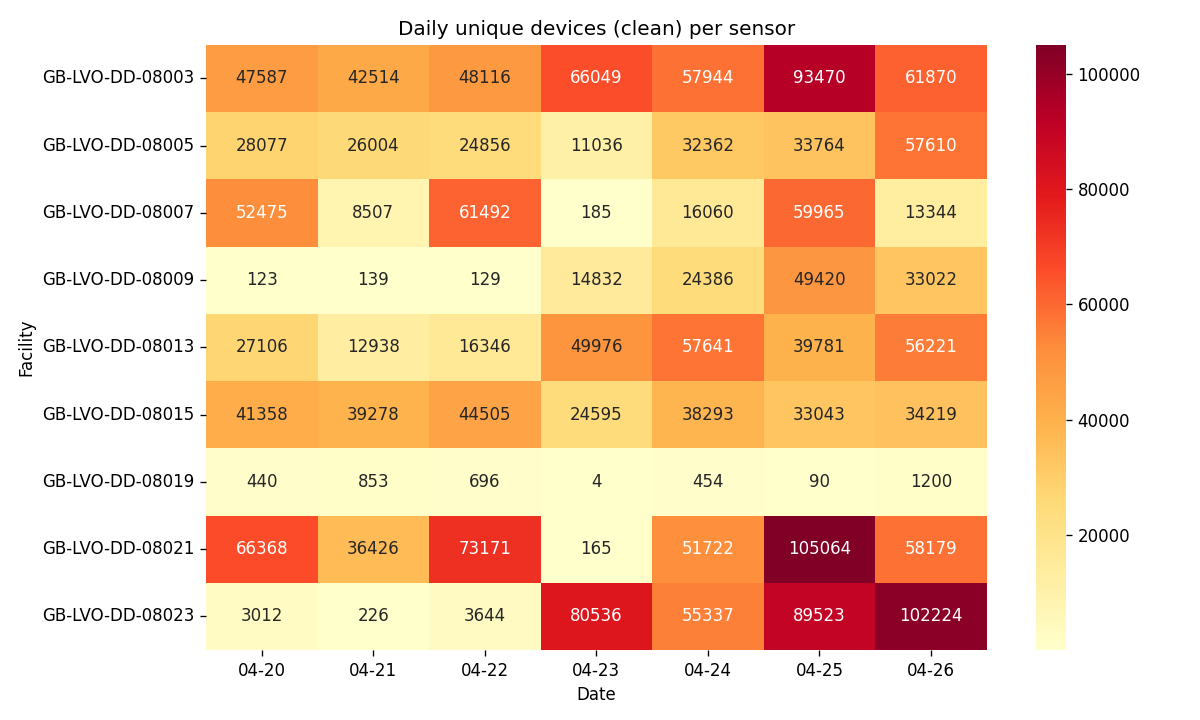

footfall_daily_device_types_stacked.png


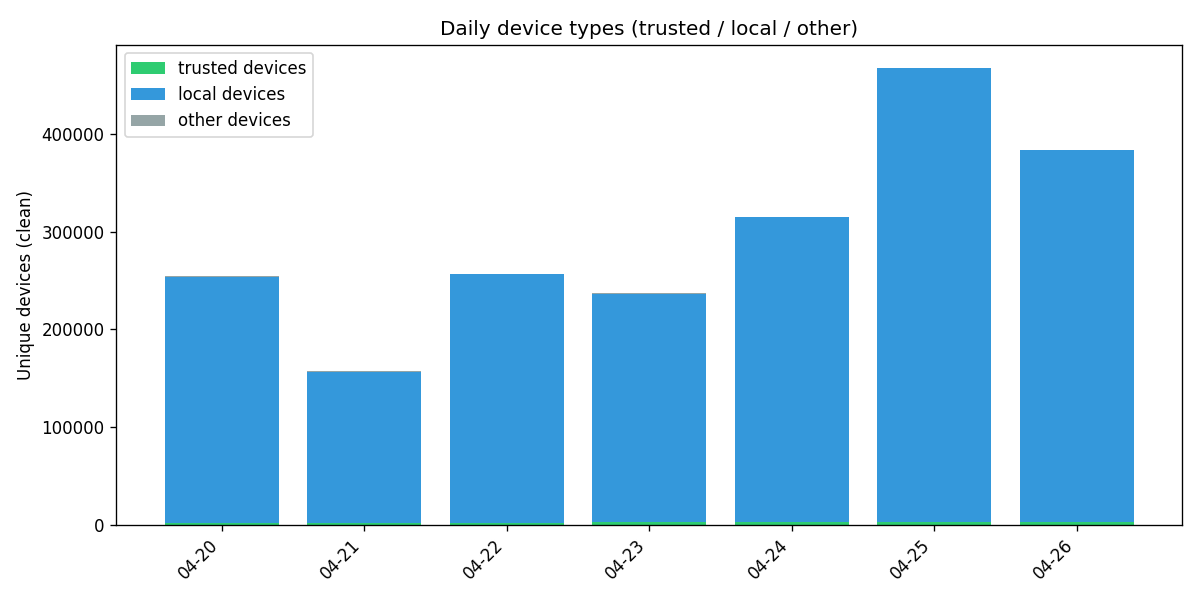

footfall_daily_estimated_vs_detected.png


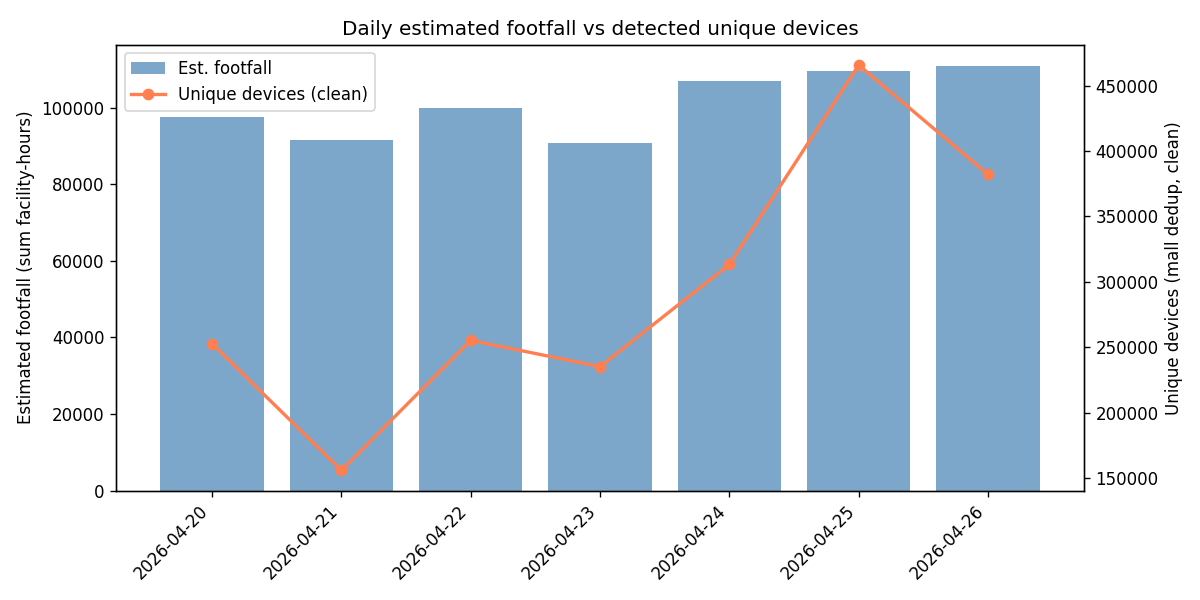

footfall_daily_sessions_and_devices.png


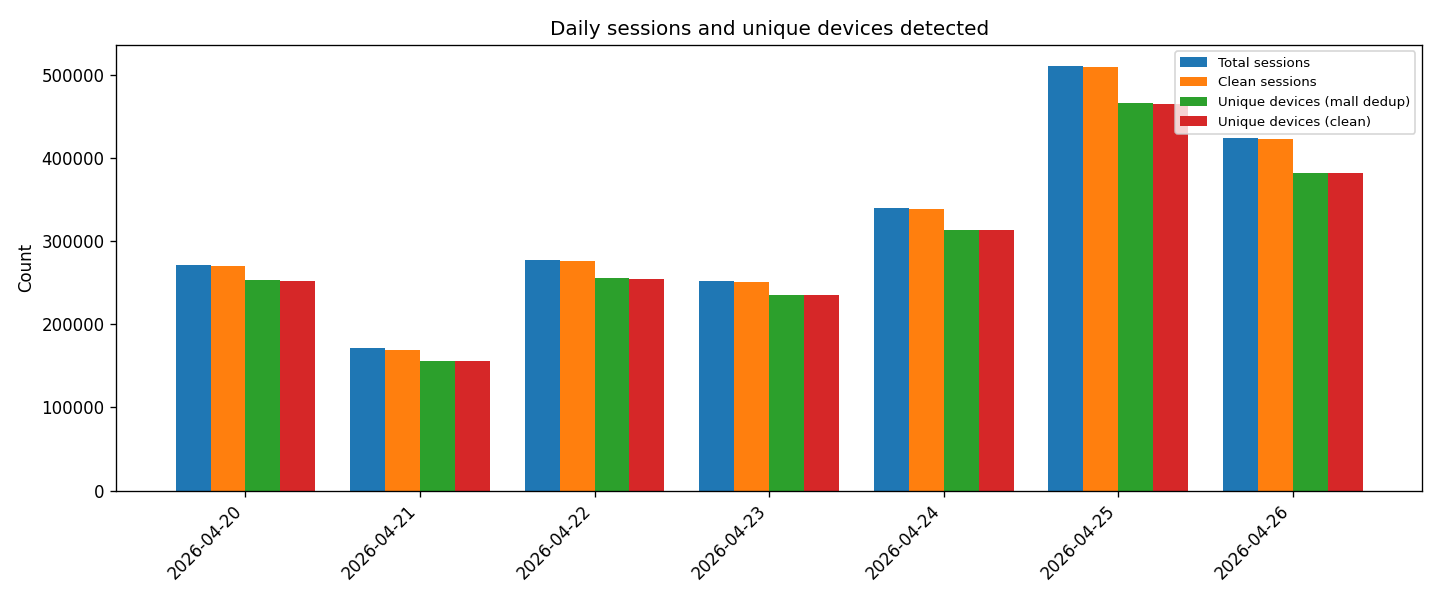

footfall_manual_calibration_overlay.png


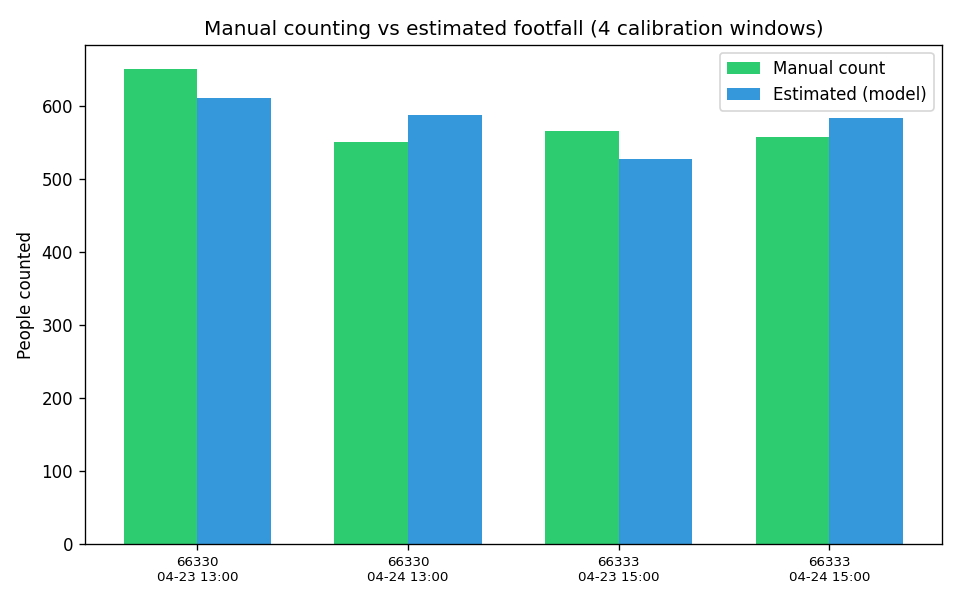

footfall_weekly_totals.png


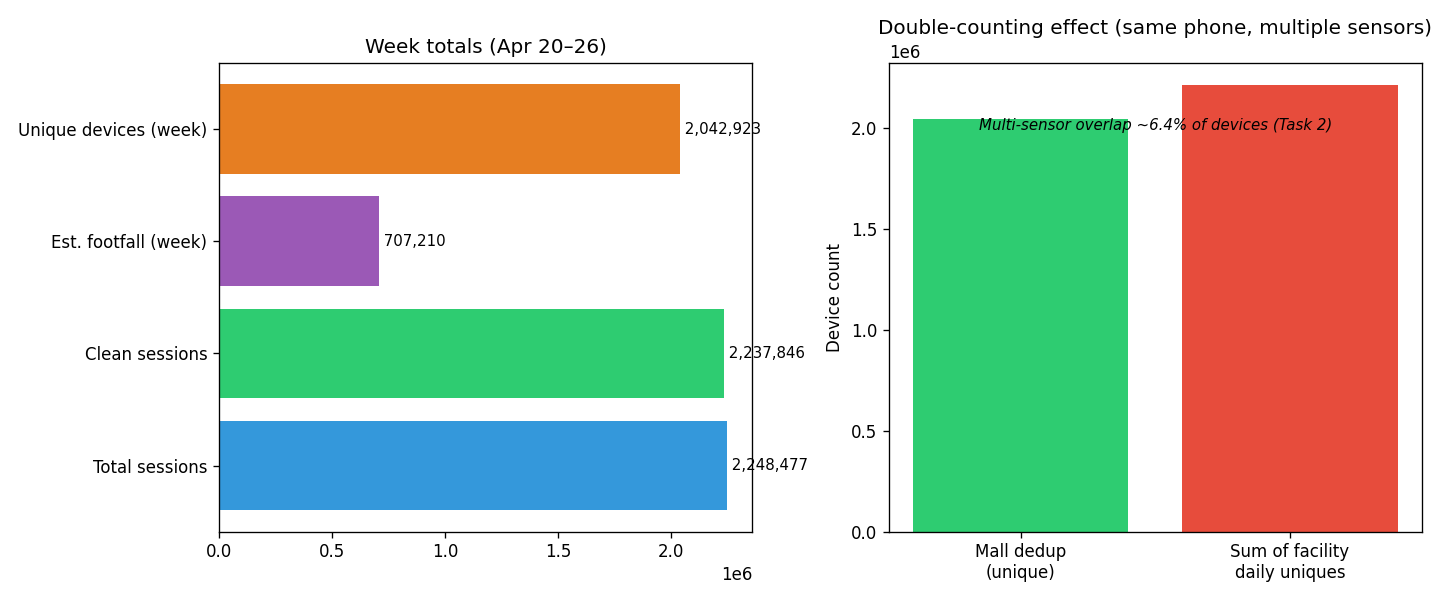

manual_calibration_overlay.png


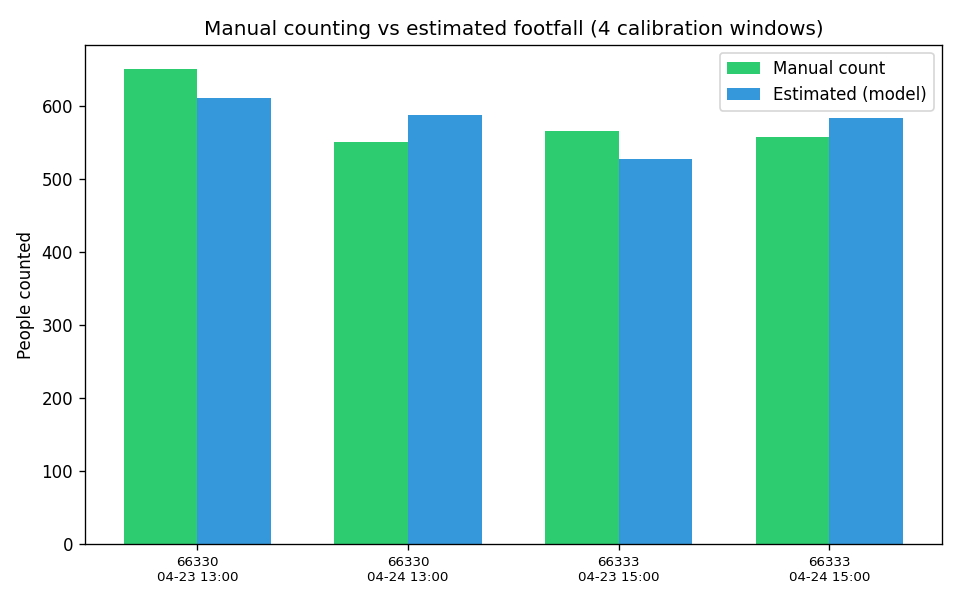

plan_a_all_facilities_daily_footfall_bars.png


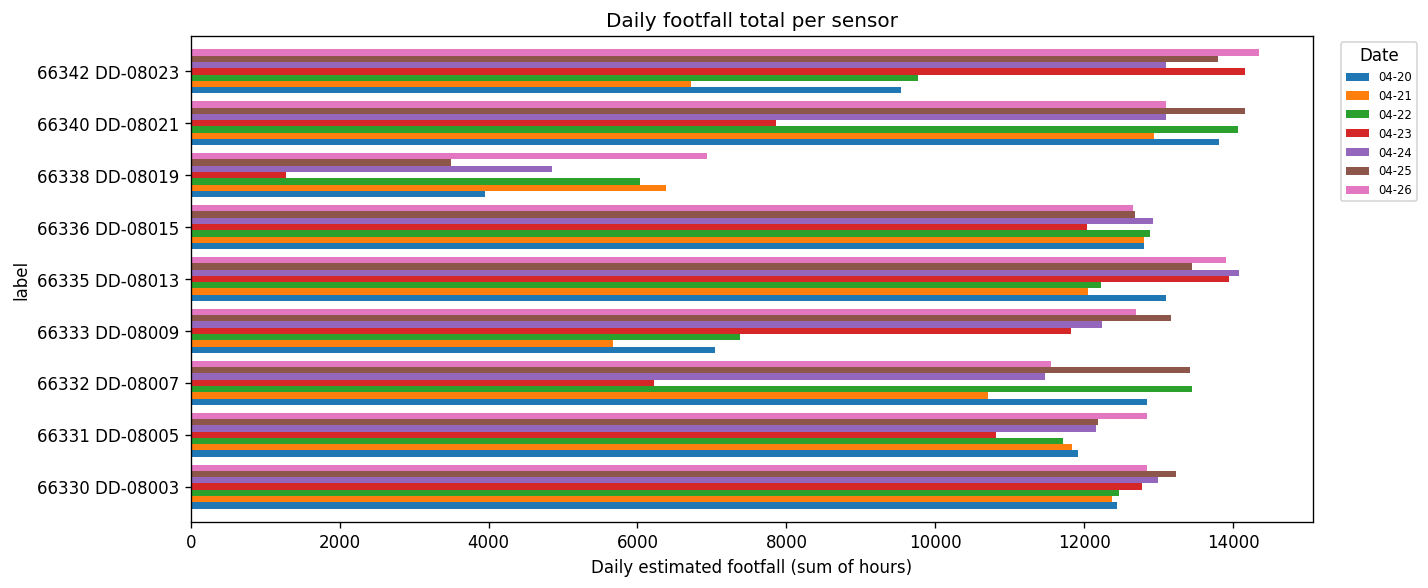

plan_a_all_facilities_daily_footfall_heatmap.png


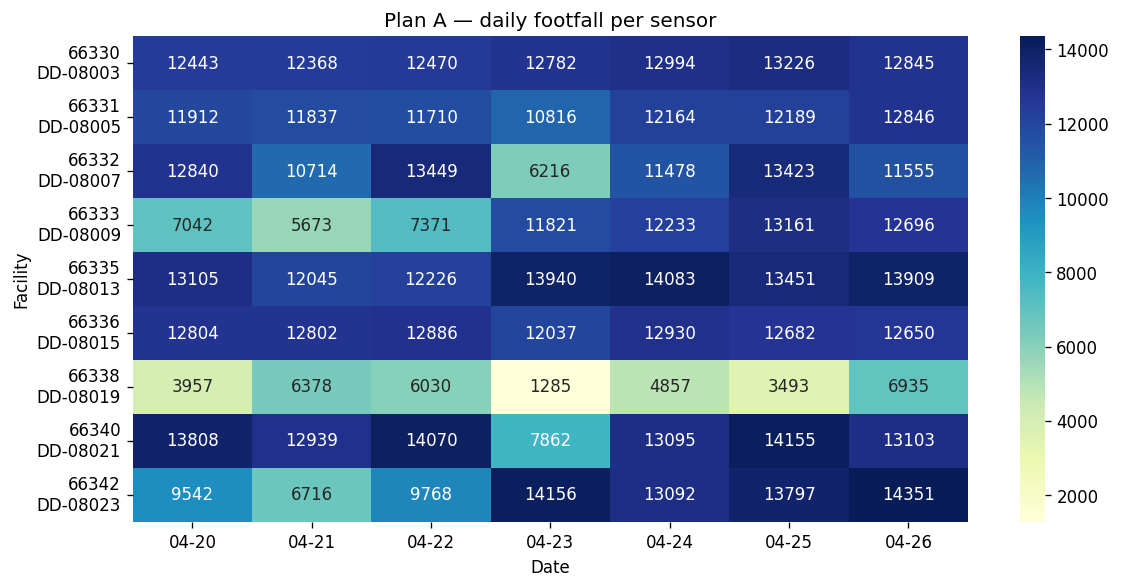

plan_a_all_facilities_hourly_devices.png


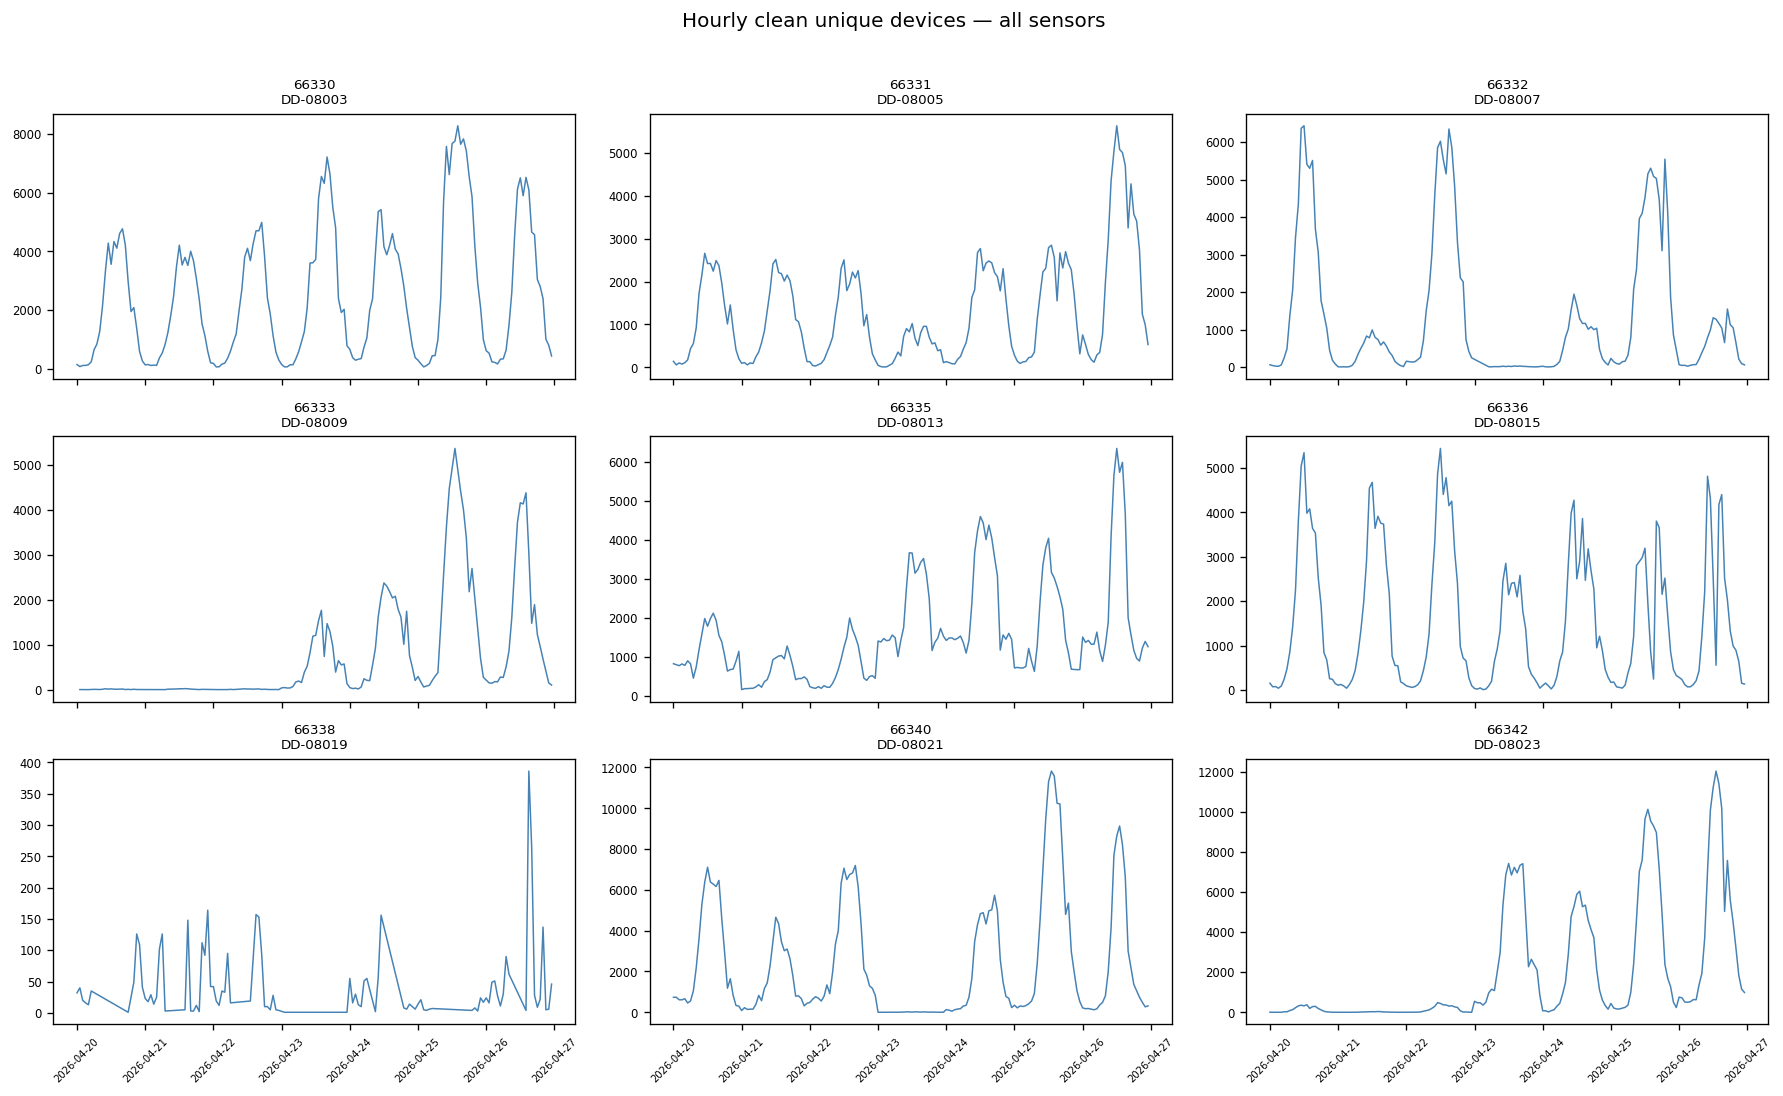

plan_a_all_facilities_hourly_footfall.png


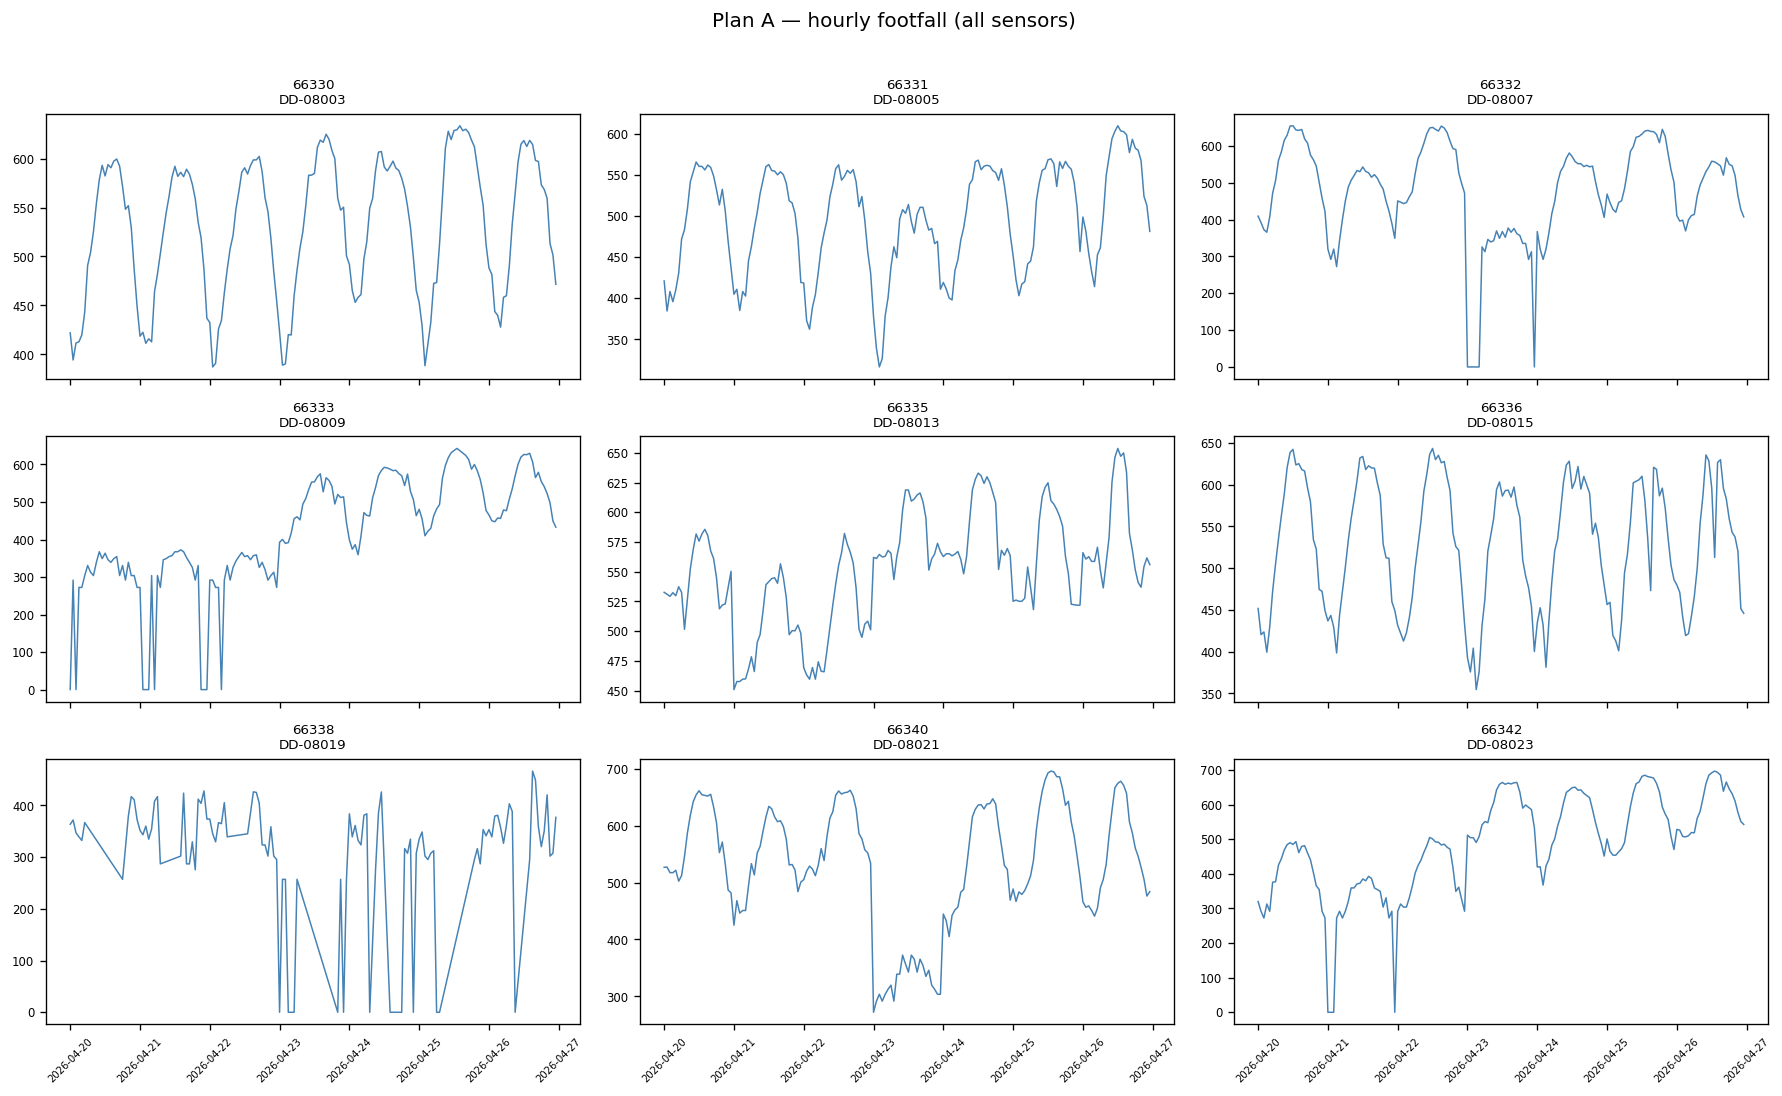

plan_c_calibration_windows.png


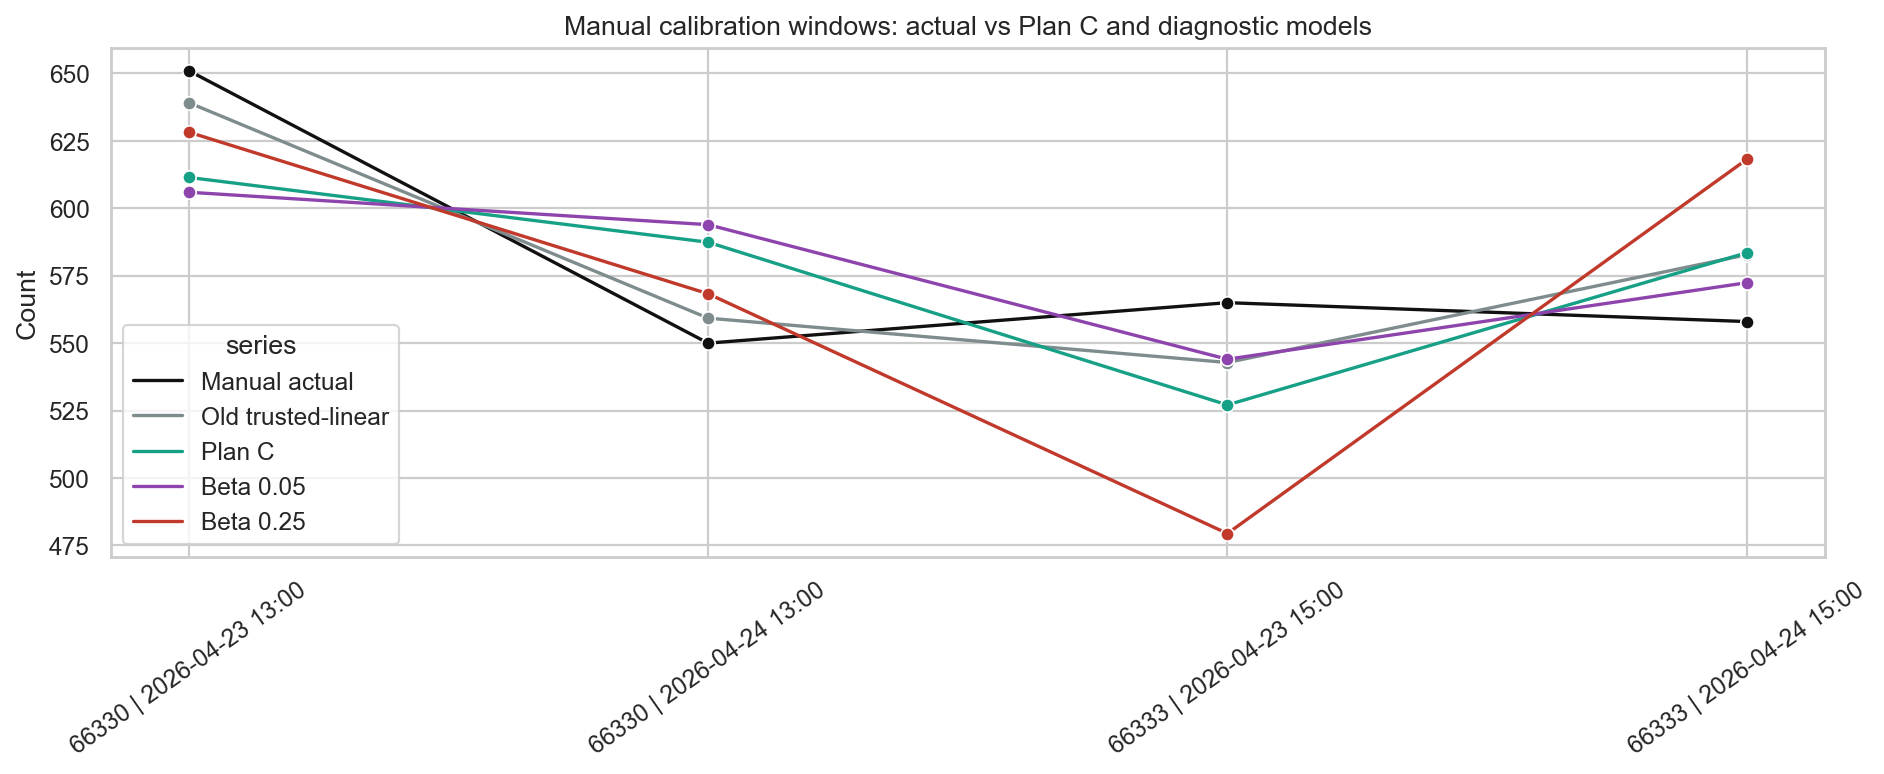

plan_c_daily_comparison.png


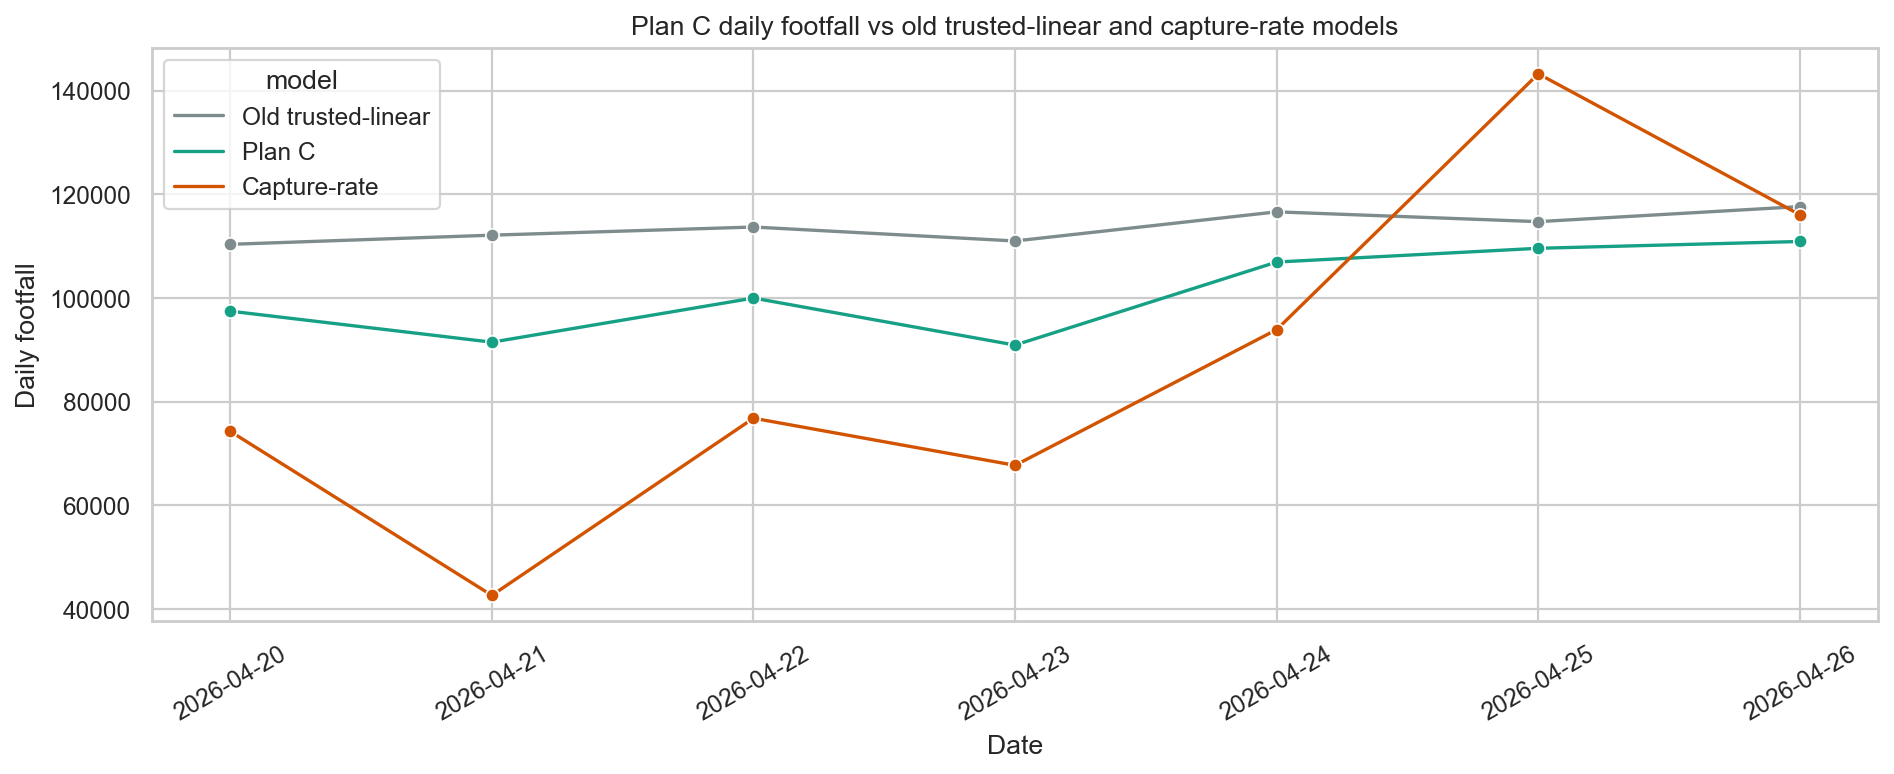

plan_c_hourly_shape.png


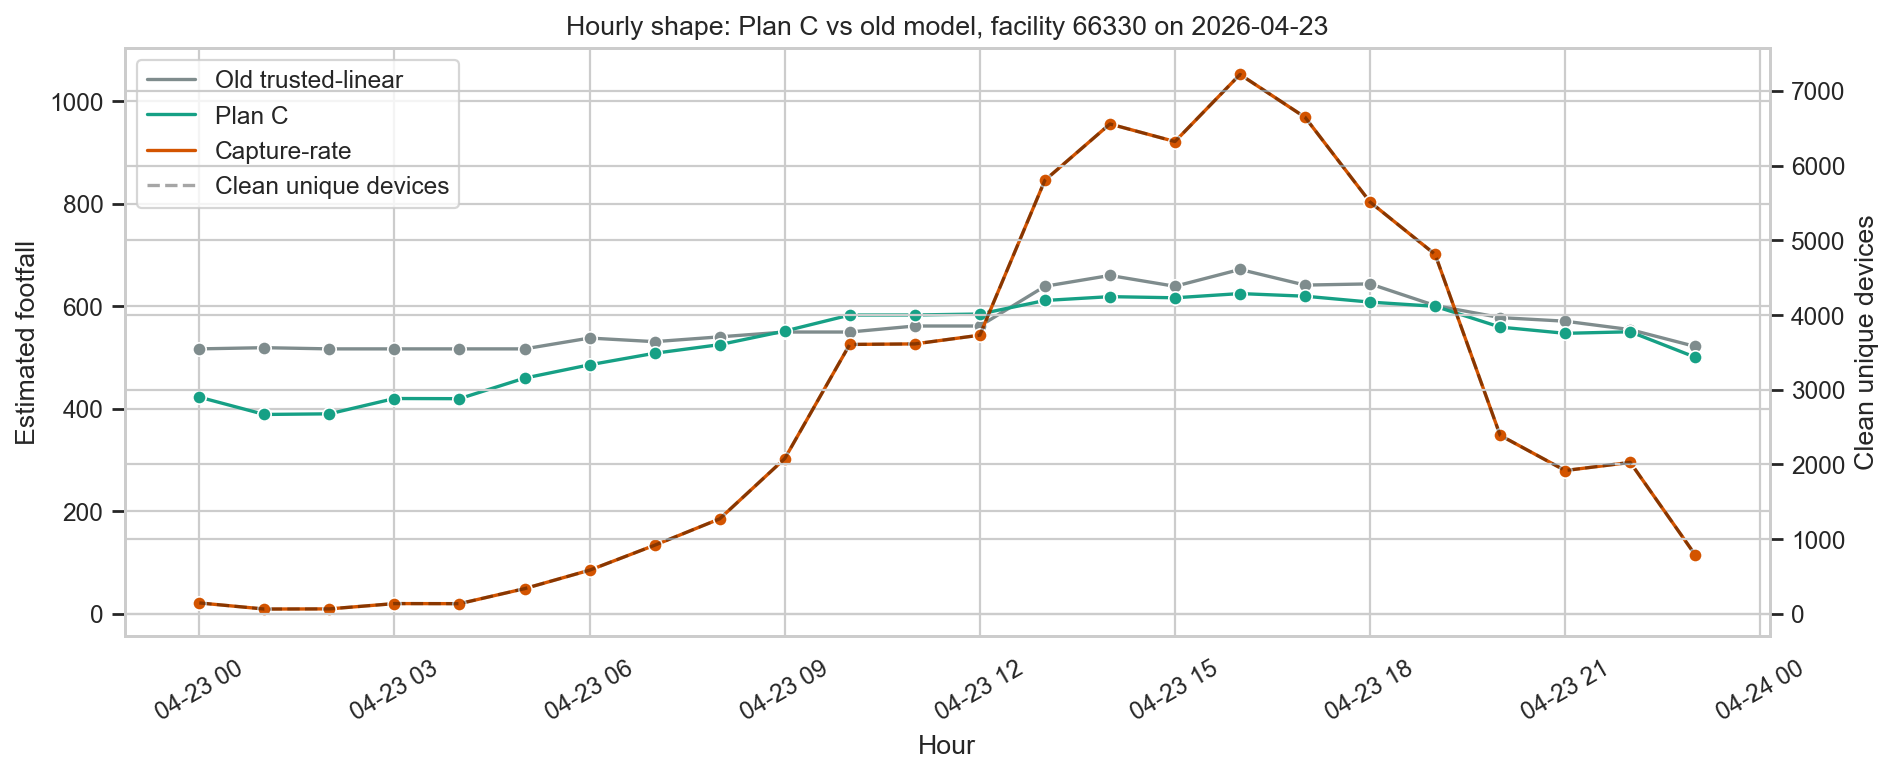

plan_c_model_error_comparison.png


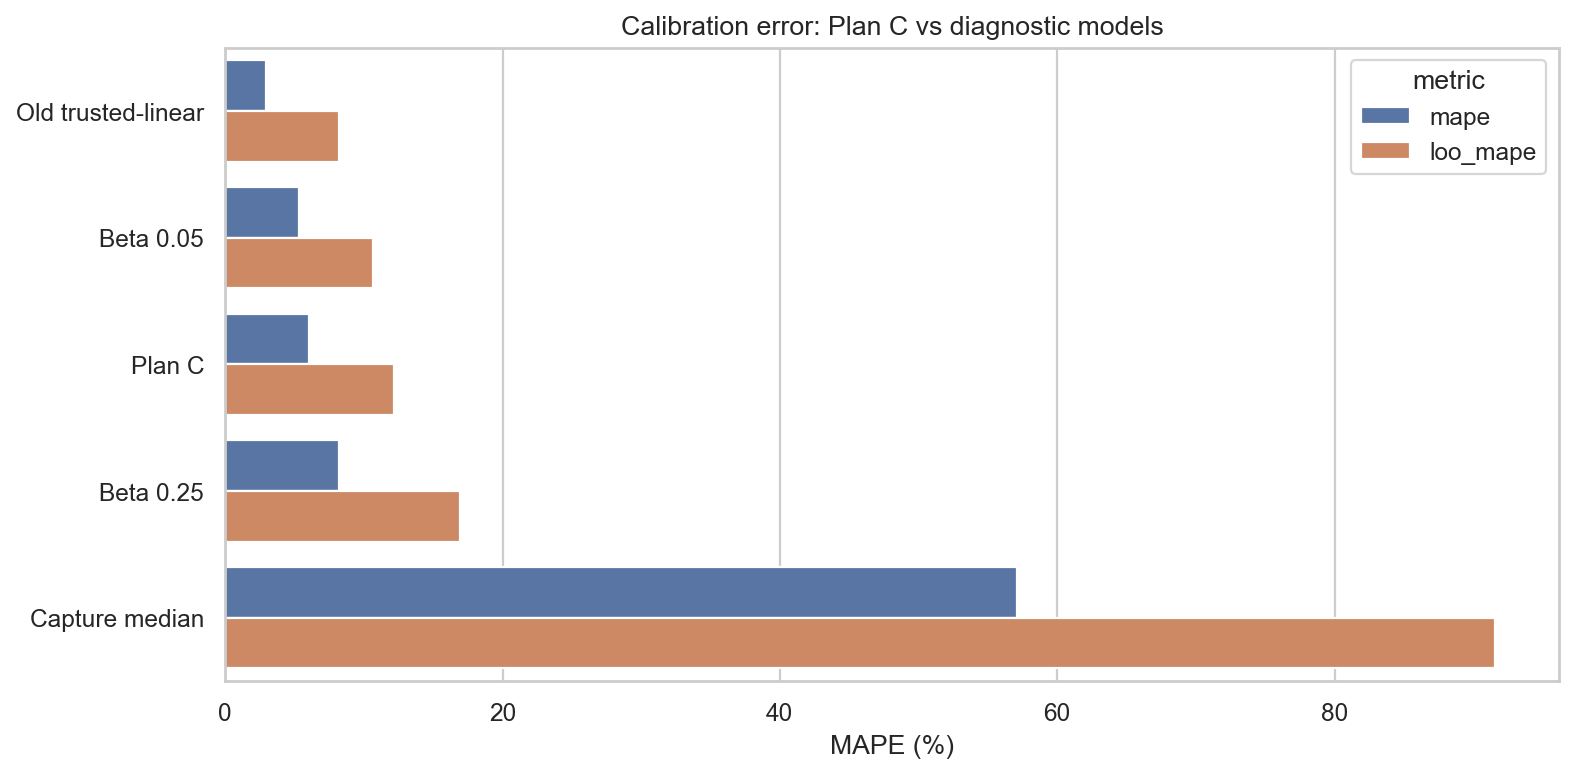

8 plots in /Users/zohaibsarwar/Documents/GitHub/Mall_Footfall_Data_Analysis_Allunite/outputs/plots/task1/plan_b
calibration_windows.png


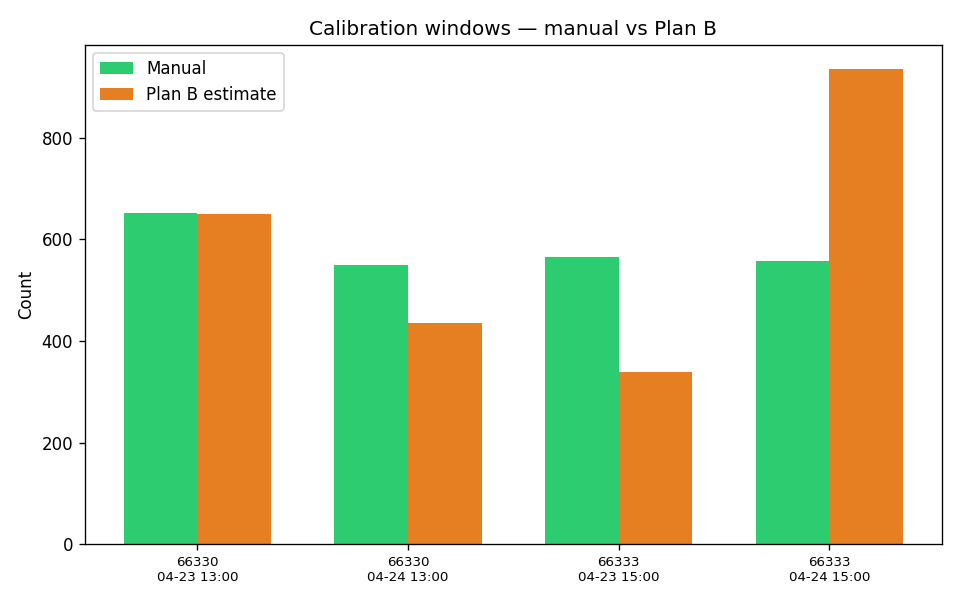

daily_plan_a_vs_b.png


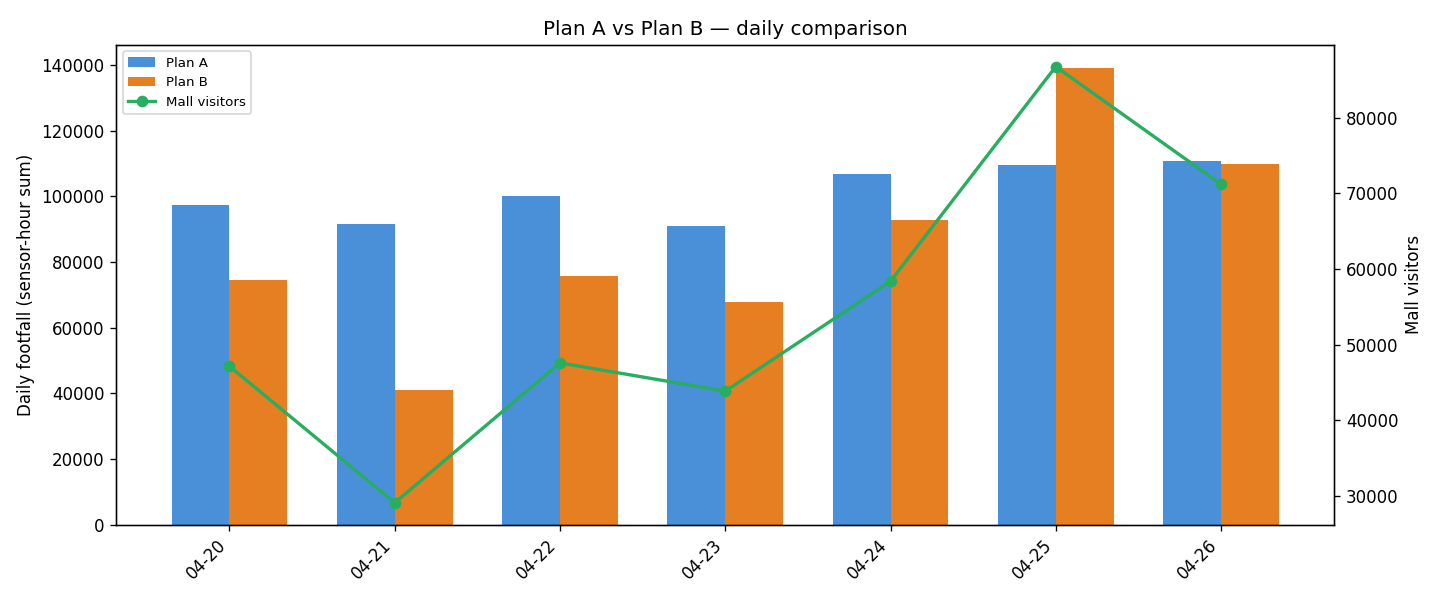

hod_v2_calibration_validation.png


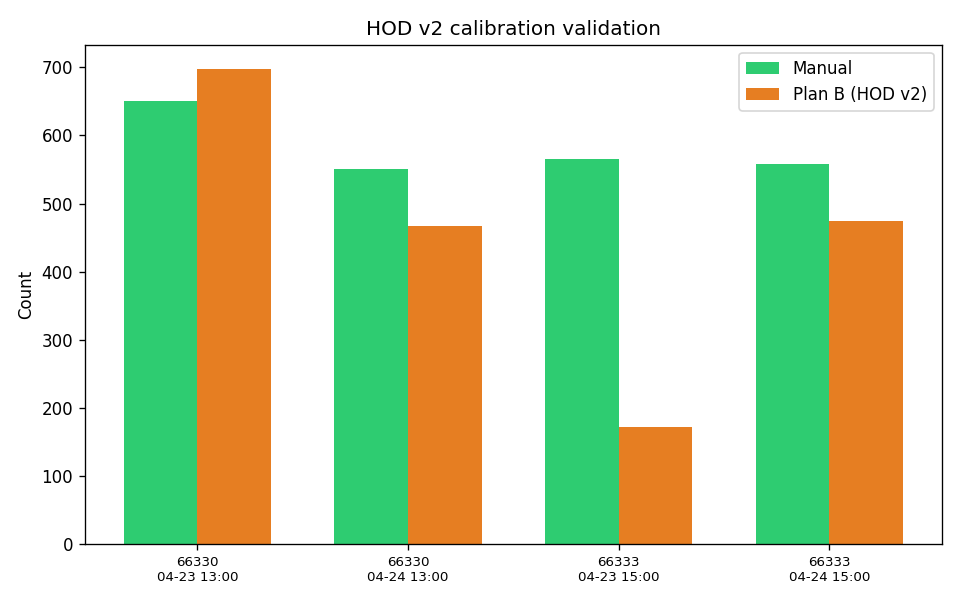

mall_visitors_daily.png


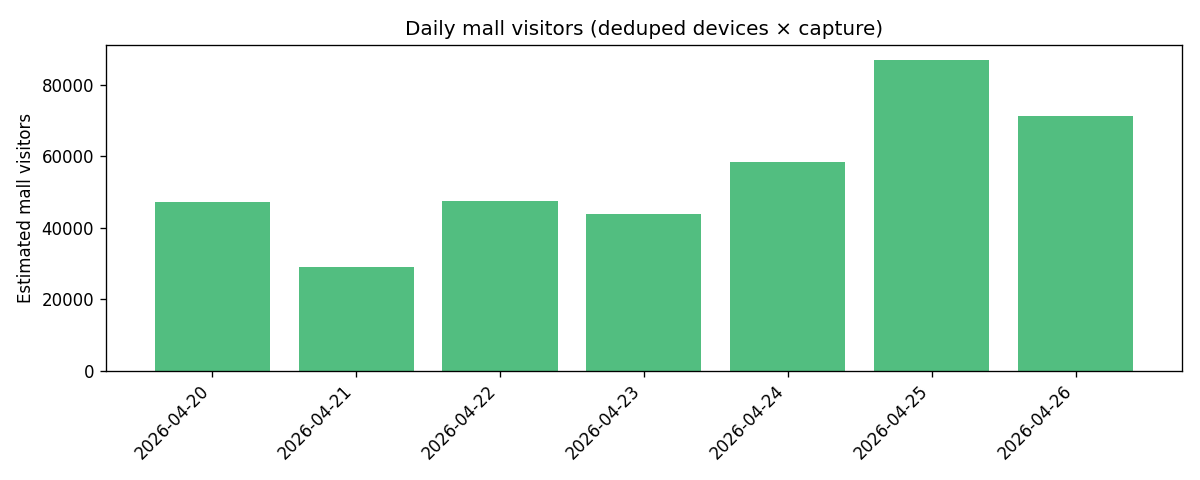

plan_b_all_facilities_daily_footfall_bars.png


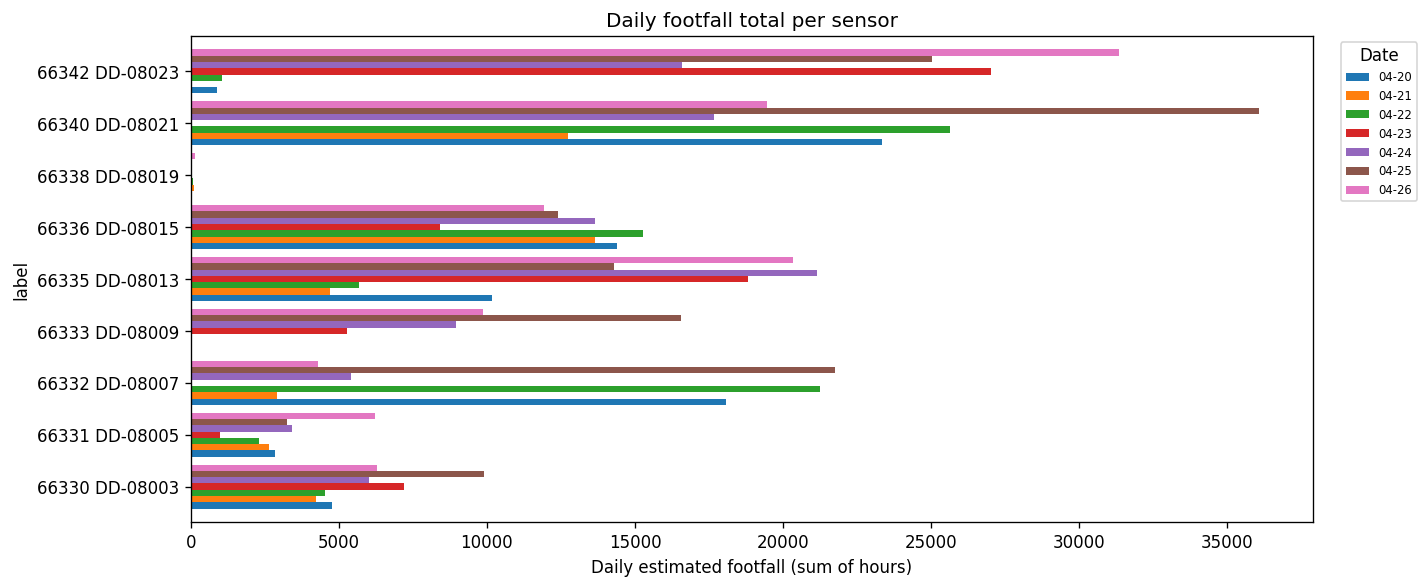

plan_b_all_facilities_daily_footfall_heatmap.png


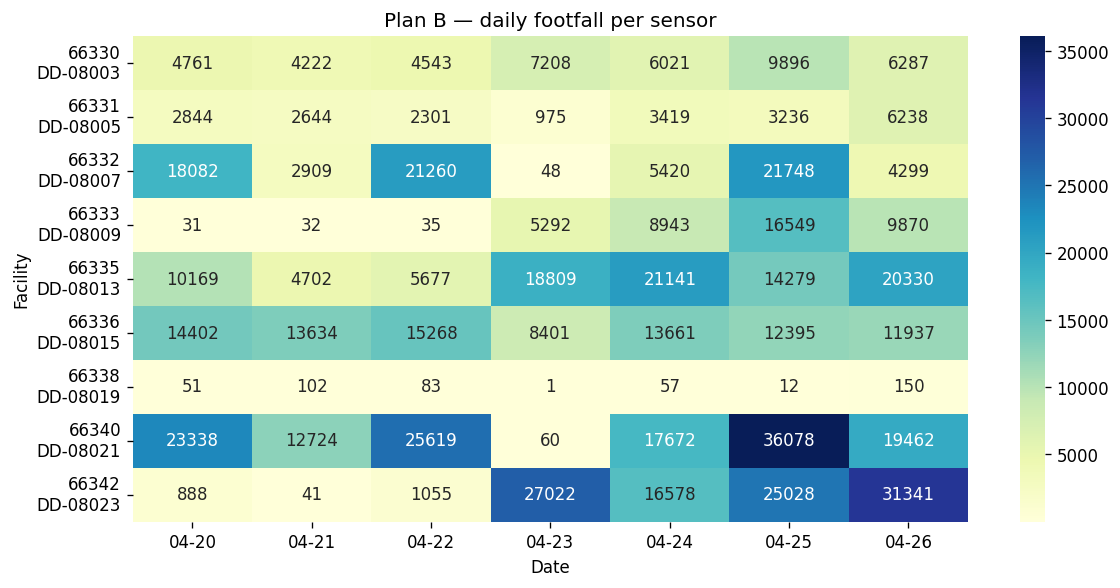

plan_b_all_facilities_hourly_devices.png


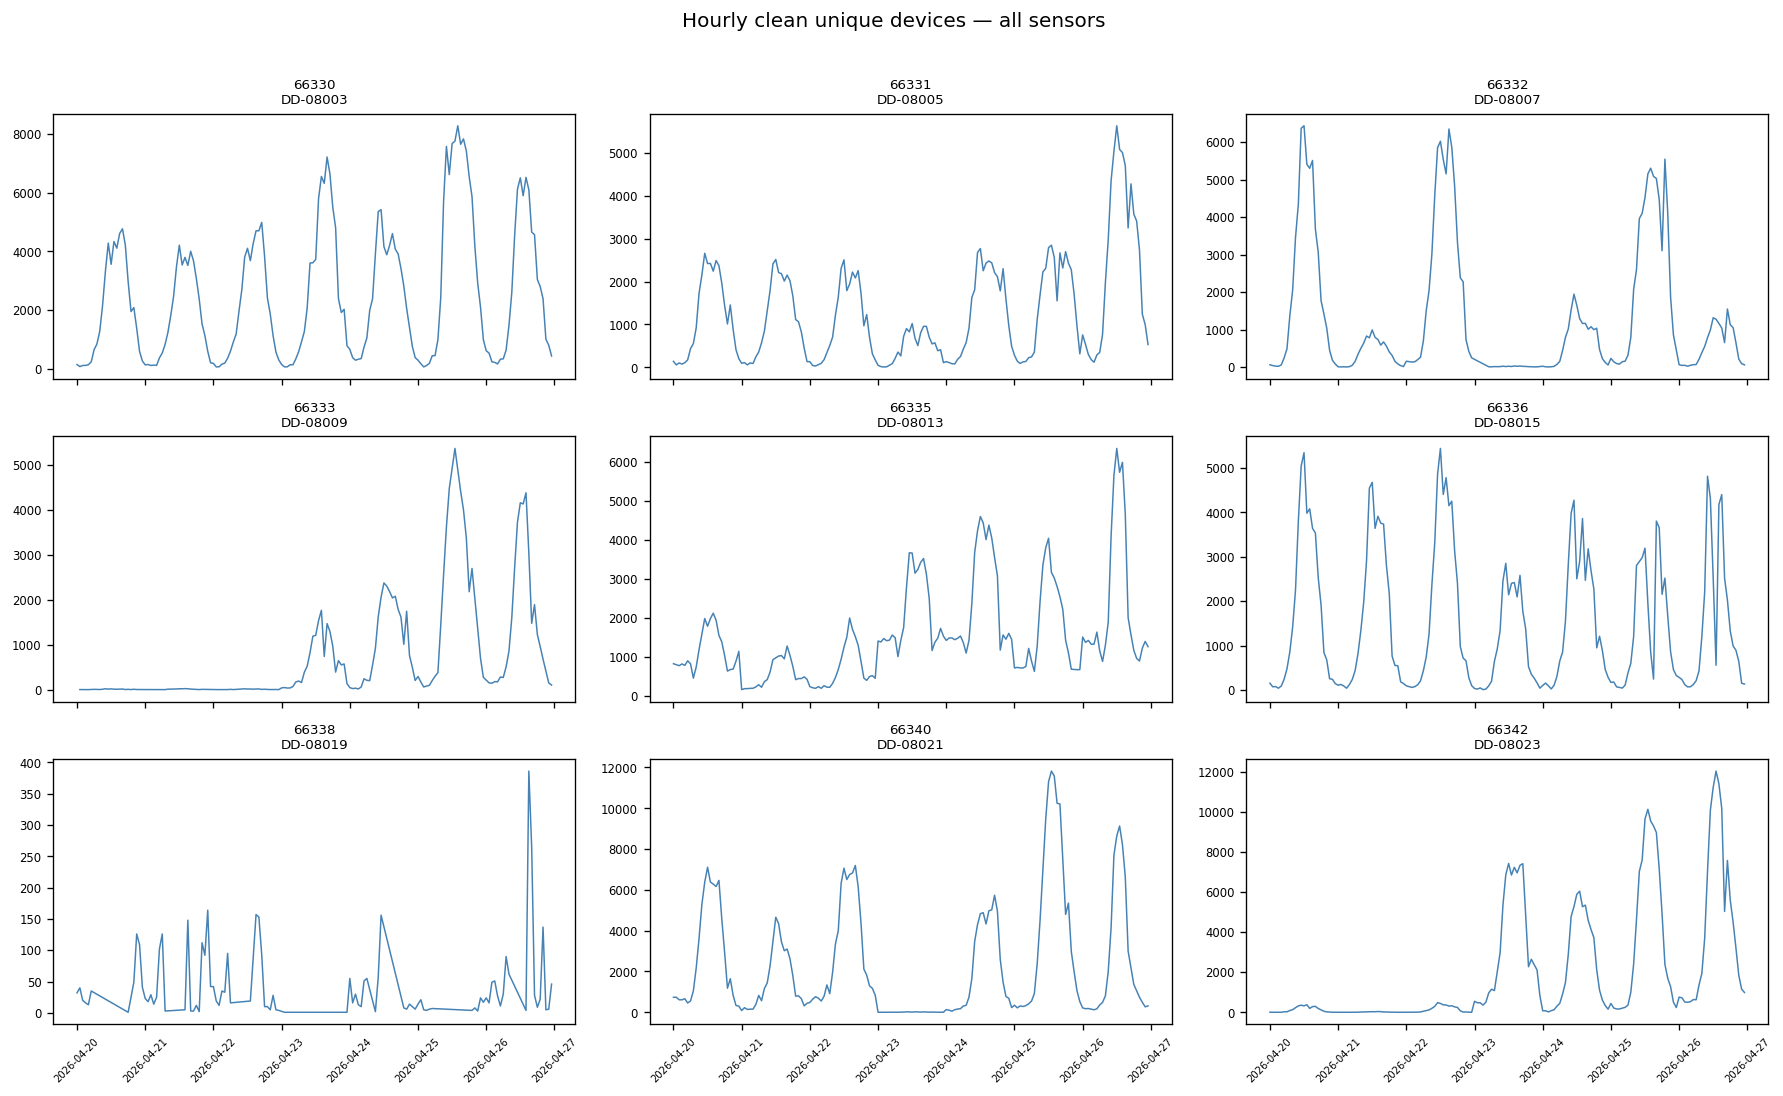

plan_b_all_facilities_hourly_footfall.png


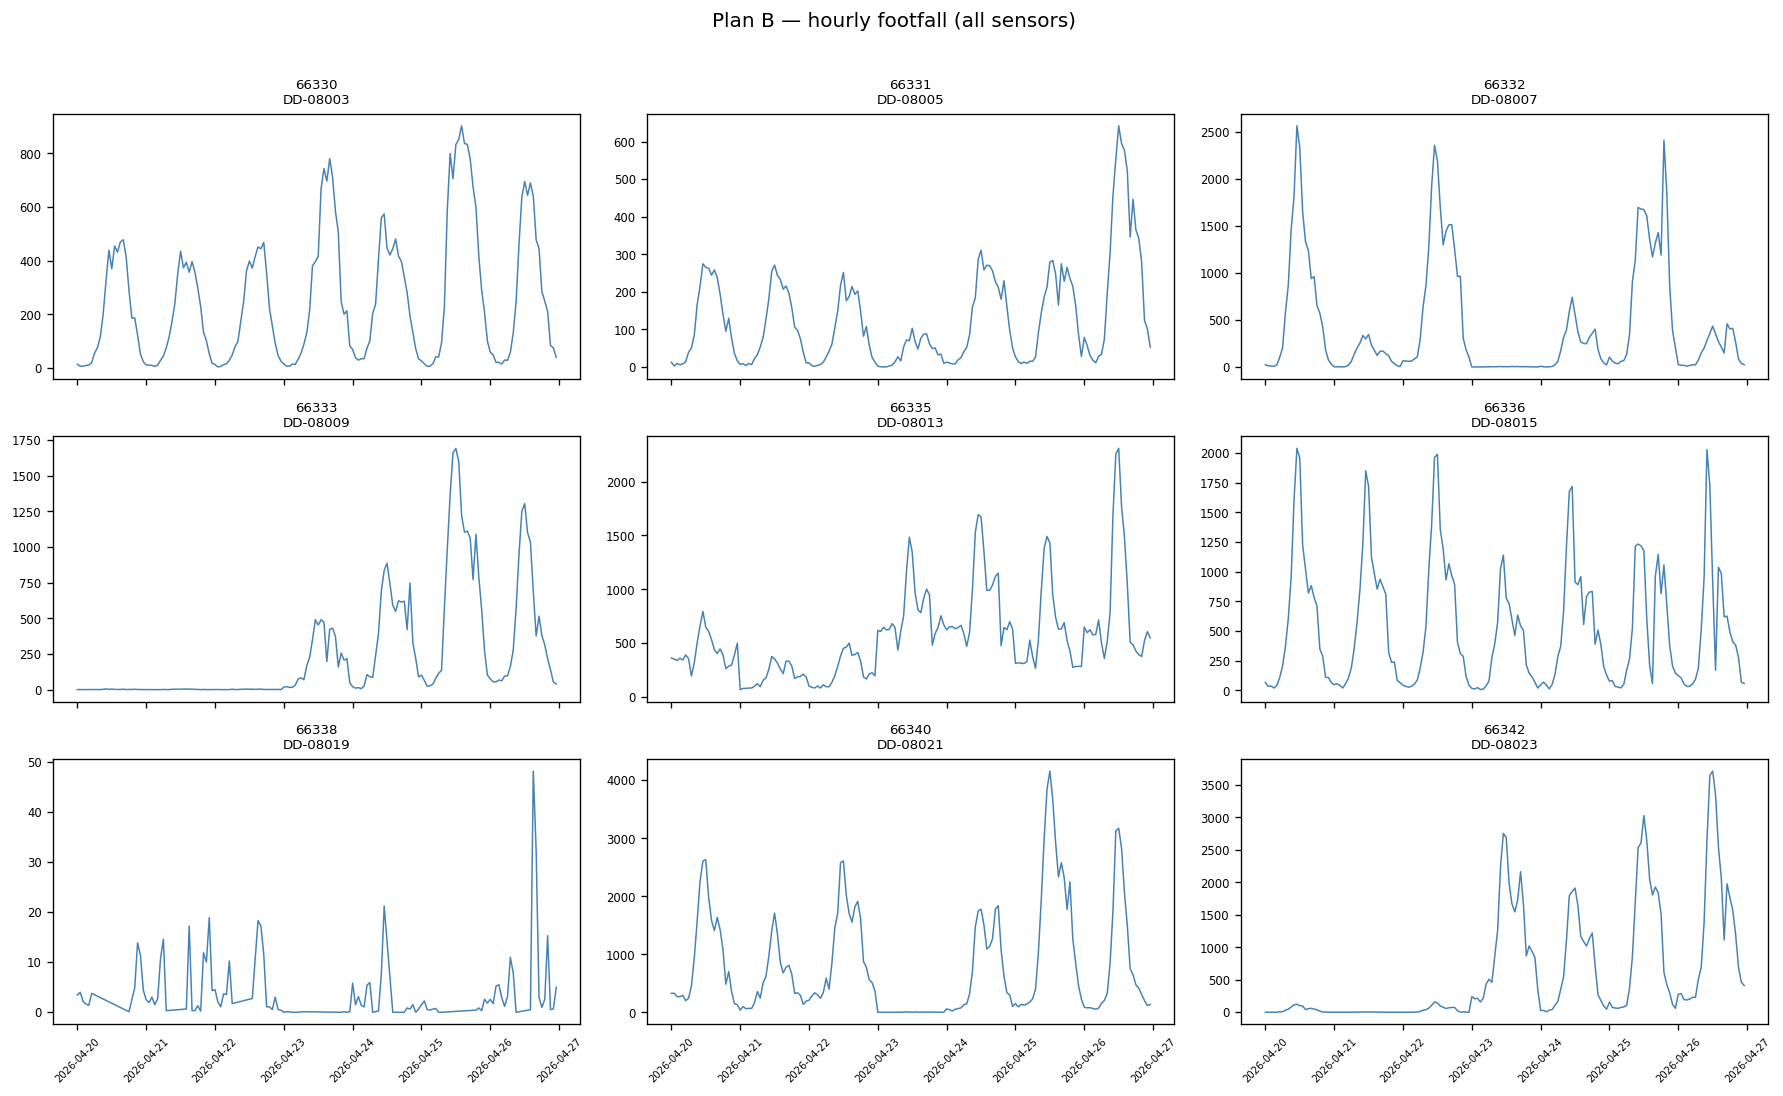

In [4]:
plot_task1(plan="both")
show_task_plots(1, plan="a")
show_task_plots(1, plan="b")

## Recommendation

**Plan C** is the best option for assignment delivery: it preserves realistic hourly/daily trend shape while staying calibrated to manual counts.

Plan A has lower calibration error on only four manual windows, but the trusted-linear model is flatter over time because its intercept dominates low-volume hours. Plan B is useful for comparison and mall-level deduplicated visitors, but the selected Task 1 delivery estimate remains Plan C.